<a href="https://colab.research.google.com/github/diemacedo12/lis4693-lis5693/blob/main/lab-4/lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing and loading libraries

In [11]:
import requests
import io
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sn
import matplotlib.pyplot as plt
%matplotlib inline

Load BBC news dataset from GitHub repo

In [12]:
url = "https://raw.githubusercontent.com/diemacedo12/lis4693-lis5693/refs/heads/main/lab-4/bbc-news-data.csv"
response = requests.get(url)
response.raise_for_status() # Raise an exception for HTTP errors
text = response.text

df = pd.read_csv(io.StringIO(text), sep='\t', header=None, names=['category', 'filename', 'title', 'content'], on_bad_lines='skip')
print(df.head(10))

features = df['content']
target = df['category']

   category  filename                              title  \
0  category  filename                              title   
1  business   001.txt  Ad sales boost Time Warner profit   
2  business   002.txt   Dollar gains on Greenspan speech   
3  business   003.txt  Yukos unit buyer faces loan claim   
4  business   004.txt  High fuel prices hit BA's profits   
5  business   005.txt  Pernod takeover talk lifts Domecq   
6  business   006.txt   Japan narrowly escapes recession   
7  business   007.txt   Jobs growth still slow in the US   
8  business   008.txt   India calls for fair trade rules   
9  business   009.txt  Ethiopia's crop production up 24%   

                                             content  
0                                            content  
1   Quarterly profits at US media giant TimeWarne...  
2   The dollar has hit its highest level against ...  
3   The owners of embattled Russian oil giant Yuk...  
4   British Airways has blamed high fuel prices f...  
5   Share

Splitting data into 70:30 ratio and performing text preprocessing

In [13]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

X_train = X_train.fillna('')
X_test = X_test.fillna('')

preprocessing = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer())
])

print("Preprocessing training data...")
train_preprocessed = preprocessing.fit_transform(X_train)

print("Preprocessing test data...")
test_preprocessed = preprocessing.transform(X_test)

Training set has 1558 samples.
Testing set has 668 samples.
Preprocessing training data...
Preprocessing test data...


Training 3 classifiers (Multinomial, SVM, and Logistic regression) and evaluating performance

In [14]:
nb_classifier = MultinomialNB()
svm_classifier = LinearSVC()
lr_classifier = LogisticRegression(multi_class="ovr")

print("Training Naive Bayes classifier...")
nb_classifier.fit(train_preprocessed, y_train)

print("Training SVM classifier...")
svm_classifier.fit(train_preprocessed, y_train)

print("Training Logistic Regression classifier...")
lr_classifier.fit(train_preprocessed, y_train)

nb_predictions = nb_classifier.predict(test_preprocessed)
svm_predictions = svm_classifier.predict(test_preprocessed)
lr_predictions = lr_classifier.predict(test_preprocessed)

print("NB Accuracy:", np.mean(nb_predictions == y_test))
print("SVM Accuracy:", np.mean(svm_predictions == y_test))
print("LR Accuracy:", np.mean(lr_predictions == y_test))

print("\nClassification Reports:")
print("Naive Bayes:\n", classification_report(y_test, nb_predictions))
print("SVM:\n", classification_report(y_test, svm_predictions))
print("Logistic Regression:\n", classification_report(y_test, lr_predictions))

Training Naive Bayes classifier...
Training SVM classifier...
Training Logistic Regression classifier...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


NB Accuracy: 0.9476047904191617
SVM Accuracy: 0.9790419161676647
LR Accuracy: 0.968562874251497

Classification Reports:
Naive Bayes:
                precision    recall  f1-score   support

     business       0.95      0.96      0.96       165
entertainment       1.00      0.83      0.91       116
     politics       0.92      0.94      0.93       119
        sport       0.94      0.99      0.97       148
         tech       0.94      0.99      0.96       120

     accuracy                           0.95       668
    macro avg       0.95      0.94      0.94       668
 weighted avg       0.95      0.95      0.95       668

SVM:
                precision    recall  f1-score   support

     business       0.96      0.98      0.97       165
entertainment       1.00      0.99      1.00       116
     politics       0.98      0.93      0.96       119
        sport       0.99      0.99      0.99       148
         tech       0.97      1.00      0.98       120

     accuracy                

Visualizing confusion matrix

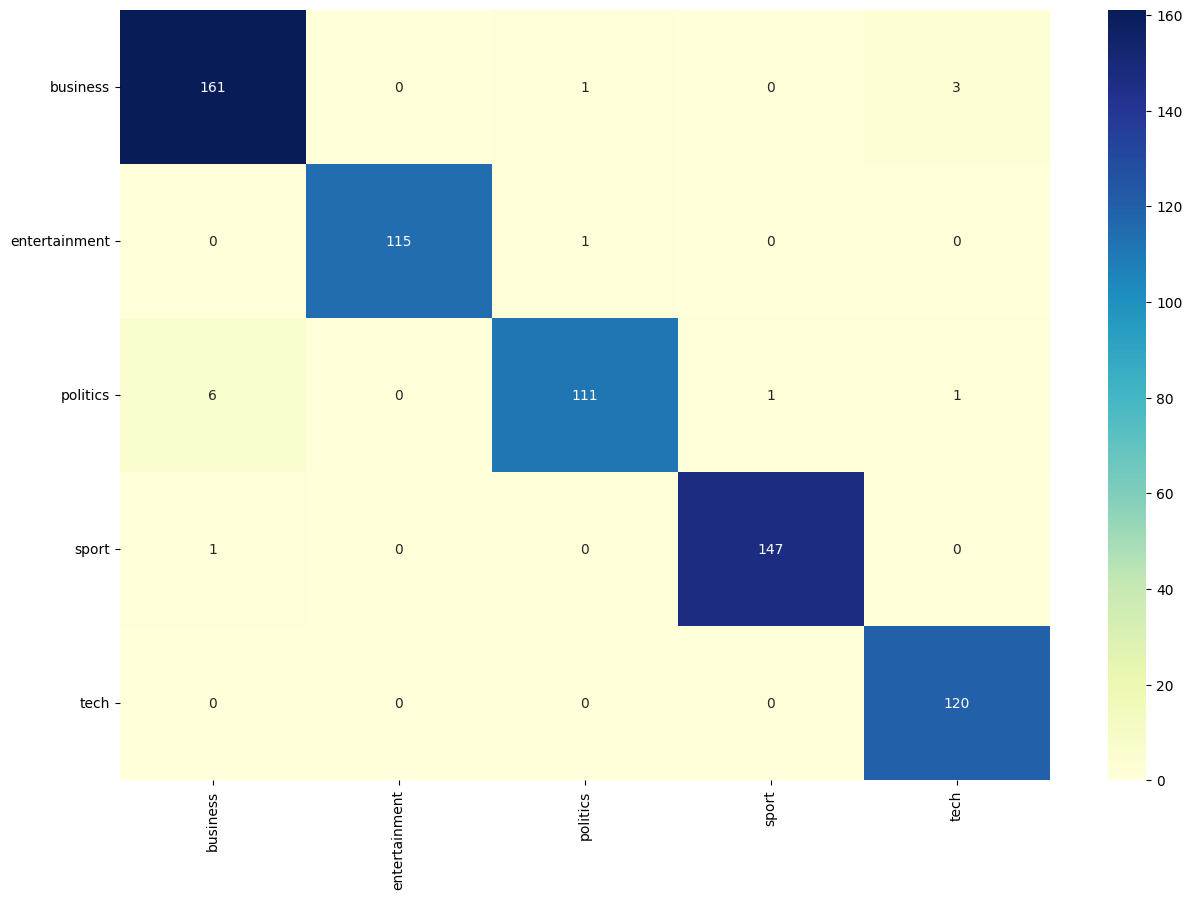

In [15]:
conf_matrix = confusion_matrix(y_test, svm_predictions)
labels = sorted(y_test.unique())
conf_matrix_df = pd.DataFrame(conf_matrix, index=labels, columns=labels)

plt.figure(figsize=(15, 10))
x = sn.heatmap(conf_matrix_df, annot=True, vmin=0, vmax=conf_matrix.max(), fmt='d', cmap="YlGnBu")
plt.yticks(rotation=0)
plt.xticks(rotation=90)
plt.show()


Predicting on pseudo dataset

In [16]:
url = "https://raw.githubusercontent.com/diemacedo12/lis4693-lis5693/refs/heads/main/lab-4/bbc-news-data.csv"
response = requests.get(url)
response.raise_for_status() # Raise an exception for HTTP errors
raw_csv_data = response.text

new_data = pd.read_csv(io.StringIO(raw_csv_data), sep='\t', header=None, names=['category', 'filename', 'title', 'content'], on_bad_lines='skip')
print(new_data.head())

new_data['content'] = new_data['content'].fillna('')
test_dtm = preprocessing.transform(new_data['content'])

test = svm_classifier.predict(test_dtm)

df2 = pd.DataFrame(test)
df2.rename(columns={0: 'predicted_category'}, inplace=True)

new_data['predicted_category'] = df2['predicted_category']
combined_df = new_data
display(combined_df.head())

combined_df.to_csv('predicted.csv', index=False)

   category  filename                              title  \
0  category  filename                              title   
1  business   001.txt  Ad sales boost Time Warner profit   
2  business   002.txt   Dollar gains on Greenspan speech   
3  business   003.txt  Yukos unit buyer faces loan claim   
4  business   004.txt  High fuel prices hit BA's profits   

                                             content  
0                                            content  
1   Quarterly profits at US media giant TimeWarne...  
2   The dollar has hit its highest level against ...  
3   The owners of embattled Russian oil giant Yuk...  
4   British Airways has blamed high fuel prices f...  


,category,filename,title,content,predicted_category
0,category,filename,title,content,category
1,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...,business
2,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...,business
3,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...,business
4,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...,business


Brief reflection:

What went well?

Everything worked as expected.
Pseudo dataset took several minutes to create.
SVM worked as intented and gave the highest accuracy (97.9%) + strong F1-scores.

What did not go well or what challenges you encountered?

Raw file was one big chunk of text, required commas and headers and to label columns with names.
Had to add target column for categories (business, entertainment, politics, sport, tech)